# Emociones en la voz — TESS

In [1]:
from pathlib import Path
from copy import deepcopy
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import torch
from torch import nn
from torch.nn import functional as F
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from IPython.display import Audio, display

RUTA_DATOS = Path(r"C:\parcial 1\TESS Toronto emotional speech set data\TESS Toronto emotional speech set data")
SEMILLA = 42
SR, N_MELS, N_TIEMPOS = 16000, 32, 32
OCULTA_1, OCULTA_2 = 128, 64
LEARNING_RATE, BATCH_SIZE = 0.001, 128
EPOCHS, PACIENCIA = 100, 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert RUTA_DATOS.is_dir(), "Revisa RUTA_DATOS"


In [2]:
registros = []
for carpeta in sorted(RUTA_DATOS.iterdir()):
    if not carpeta.is_dir() or not carpeta.name.startswith(("OAF_", "YAF_")):
        continue
    emocion = carpeta.name.split("_", 1)[1].lower()
    emocion = "surprise" if emocion.startswith("pleasant") else emocion
    for archivo in sorted(carpeta.iterdir()):
        if archivo.is_file() and archivo.suffix.lower() == ".wav":
            registros.append((str(archivo), archivo.stem.split("_")[1], emocion))

df = pd.DataFrame(registros, columns=["ruta", "palabra", "emocion"])
clases = sorted(df["emocion"].unique())
y = df["emocion"].map({c: i for i, c in enumerate(clases)}).to_numpy()
palabras = np.random.default_rng(SEMILLA).permutation(sorted(df["palabra"].unique()))
a, b = int(len(palabras) * 0.64), int(len(palabras) * 0.80)
idx_train, idx_val, idx_test = [
    np.flatnonzero(df["palabra"].isin(grupo))
    for grupo in (palabras[:a], palabras[a:b], palabras[b:])
]
print(f"Audios: {len(df)} | Clases: {len(clases)} | Train/val/test: {len(idx_train)}/{len(idx_val)}/{len(idx_test)}")


Audios: 2800 | Clases: 7 | Train/val/test: 1792/448/560


In [3]:
def extraer_caracteristicas(ruta):
    audio, sr = librosa.load(ruta, sr=SR, mono=True)

    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=N_MELS,
        n_fft=512, hop_length=256
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    matriz = torch.from_numpy(mel_db).float().unsqueeze(0)
    matriz = F.adaptive_avg_pool1d(matriz, N_TIEMPOS)

    return matriz.flatten().numpy()

inicio = perf_counter()
X = np.stack([extraer_caracteristicas(ruta) for ruta in df["ruta"]])
media = X[idx_train].mean(axis=0)
desviacion = np.maximum(X[idx_train].std(axis=0), 1e-8)

def preparar_tensores(indices):
    return (
        torch.tensor((X[indices] - media) / desviacion, dtype=torch.float32, device=device),
        torch.tensor(y[indices], dtype=torch.long, device=device)
    )

X_train, y_train = preparar_tensores(idx_train)
X_val, y_val = preparar_tensores(idx_val)
X_test, y_test = preparar_tensores(idx_test)
print(f"X: {X.shape} | Preparación: {perf_counter() - inicio:.1f} s | {device}")


c:\Users\jhonn\miniconda3\envs\arquitectura\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


X: (2800, 1024) | Preparación: 111.8 s | cuda


In [4]:
torch.manual_seed(SEMILLA)

modelo = nn.Sequential(
    nn.Linear(X_train.shape[1], OCULTA_1),
    nn.ReLU(),
    nn.Linear(OCULTA_1, OCULTA_2),
    nn.ReLU(),
    nn.Linear(OCULTA_2, len(clases))
).to(device)

criterio = nn.CrossEntropyLoss()
optimizador = torch.optim.Adam(
    modelo.parameters(), lr=LEARNING_RATE
)


In [5]:
def entrenar(modelo, optimizador, criterio, X_train, y_train,
             X_val, y_val, epochs, batch_size, paciencia):

    historial = []
    mejor_loss = float("inf")
    mejores_pesos = deepcopy(modelo.state_dict())
    mejor_epoca = 0
    sin_mejora = 0
    inicio = perf_counter()

    for epoca in range(1, epochs + 1):
        modelo.train()
        orden = torch.randperm(len(X_train), device=X_train.device)

        for indices in orden.split(batch_size):
            optimizador.zero_grad()
            salida = modelo(X_train[indices])
            loss = criterio(salida, y_train[indices])
            loss.backward()
            optimizador.step()

        modelo.eval()
        with torch.no_grad():
            salida_train = modelo(X_train)
            salida_val = modelo(X_val)

            loss_train = criterio(salida_train, y_train).item()
            loss_val = criterio(salida_val, y_val).item()

            acc_train = (
                salida_train.argmax(1) == y_train
            ).float().mean().item()

            acc_val = (
                salida_val.argmax(1) == y_val
            ).float().mean().item()

        historial.append({
            "loss_train": loss_train, "loss_val": loss_val,
            "acc_train": acc_train, "acc_val": acc_val
        })

        if loss_val < mejor_loss:
            mejor_loss = loss_val
            mejores_pesos = deepcopy(modelo.state_dict())
            mejor_epoca = epoca
            sin_mejora = 0
        else:
            sin_mejora += 1

        if sin_mejora >= paciencia:
            print("Parada temprana por falta de mejora.")
            break

    modelo.load_state_dict(mejores_pesos)

    if X_train.is_cuda:
        torch.cuda.synchronize()

    print(f"\nMejor época: {mejor_epoca}")
    print(f"Tiempo de entrenamiento: {perf_counter() - inicio:.1f} segundos")

    return pd.DataFrame(historial)

historial = entrenar(
    modelo, optimizador, criterio,
    X_train, y_train, X_val, y_val,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    paciencia=PACIENCIA
)


Parada temprana por falta de mejora.

Mejor época: 43
Tiempo de entrenamiento: 14.5 segundos


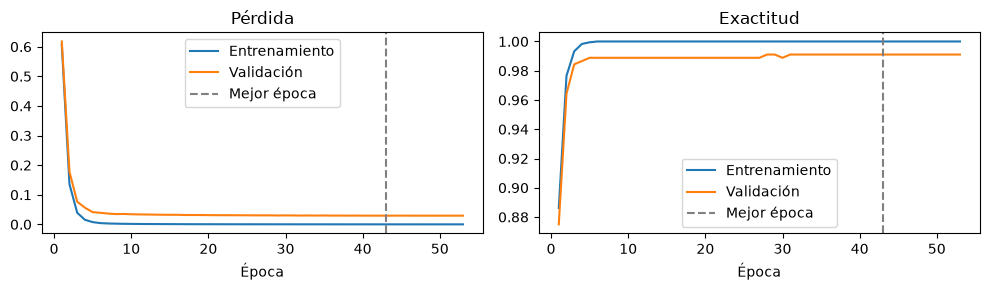

In [6]:
epocas = np.arange(1, len(historial) + 1)
mejor_epoca = historial["loss_val"].to_numpy().argmin() + 1
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, metrica, titulo in zip(axes, ["loss", "acc"], ["Pérdida", "Exactitud"]):
    ax.plot(epocas, historial[f"{metrica}_train"], label="Entrenamiento")
    ax.plot(epocas, historial[f"{metrica}_val"], label="Validación")
    ax.axvline(mejor_epoca, color="gray", linestyle="--", label="Mejor época")
    ax.set(title=titulo, xlabel="Época")
    ax.legend()
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

       angry     1.0000    0.9875    0.9937        80
     disgust     0.9756    1.0000    0.9877        80
        fear     1.0000    1.0000    1.0000        80
       happy     1.0000    1.0000    1.0000        80
     neutral     1.0000    0.9875    0.9937        80
         sad     0.9877    1.0000    0.9938        80
    surprise     1.0000    0.9875    0.9937        80

    accuracy                         0.9946       560
   macro avg     0.9948    0.9946    0.9947       560
weighted avg     0.9948    0.9946    0.9947       560



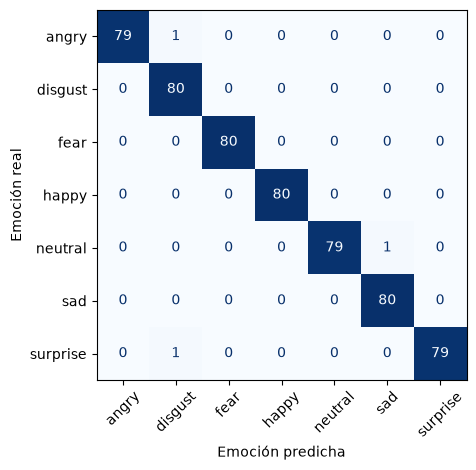

In [7]:
modelo.eval()
with torch.no_grad():
    predicciones = modelo(X_test).argmax(1).cpu().numpy()
reales = y_test.cpu().numpy()
print(classification_report(reales, predicciones, labels=range(len(clases)),
                            target_names=clases, digits=4, zero_division=0))
ConfusionMatrixDisplay.from_predictions(
    reales, predicciones, labels=range(len(clases)), display_labels=clases,
    cmap="Blues", xticks_rotation=45, colorbar=False, values_format="d"
)
plt.xlabel("Emoción predicha")
plt.ylabel("Emoción real")
plt.tight_layout()
plt.show()


In [8]:
POSICION = 150
print("Real:", clases[reales[POSICION]], "| Predicha:", clases[predicciones[POSICION]])
display(Audio(filename=df.iloc[idx_test[POSICION]]["ruta"]))


Real: happy | Predicha: happy
